In [1]:
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
import numpy as np

-----------------------------------------------------------

In [2]:
import scipy.interpolate as sip
from scipy.optimize import curve_fit

In [3]:
test_files = np.load('../../Data/GWs_data/dL_samples.npz')
print(test_files.files)

['LVK_z005', 'LVK_z01', 'LVK_z02', 'CE_z005', 'CE_z01', 'CE_z02', 'CE_z05', 'CE_z075', 'CE_z1', 'CE_z15', 'CE_z2', 'CE_z02_BBH']


In [4]:
dist_names = test_files.files[:-1]

In [5]:
dist_names[:3]

['LVK_z005', 'LVK_z01', 'LVK_z02']

In [6]:
dist_names

['LVK_z005',
 'LVK_z01',
 'LVK_z02',
 'CE_z005',
 'CE_z01',
 'CE_z02',
 'CE_z05',
 'CE_z075',
 'CE_z1',
 'CE_z15',
 'CE_z2']

In [7]:
z_LVK_range = [0.05, 0.1, 0.2]
z_CE_range = [0.05, 0.1, 0.2, 0.5, 0.75, 1.0, 1.5, 2.0]

In [8]:
np.random.choice(np.arange(0, 10), size=10, replace=True)

array([3, 0, 2, 5, 0, 3, 2, 7, 6, 7])

In [9]:
test_files['LVK_z005']

array([230.48190444, 106.67536999, 108.26720167, ..., 240.12612196,
       250.50196788, 254.72363901])

In [10]:
dl_normed = renormalise_dist_posterior('LVK_z005', 10)
dl_normed

NameError: name 'renormalise_dist_posterior' is not defined

In [ ]:
gaussian_kde(dl_normed)

In [15]:
def renormalise_dist_posterior(sample_name, N_draw, alpha=-2):
    dist_samples = test_files[sample_name]

    # Re-weight weights
    p_values = (dist_samples**alpha)/np.sum(dist_samples**alpha)

    # Choose distance samples indices, based on weights
    indices_all = np.arange(0, len(dist_samples))
    indices_selected = np.random.choice(indices_all, size=N_draw, replace=True, p=p_values)
    
    ## The normalised samples
    DL_normed = dist_samples[indices_selected]
    
    # # Calculate kde
    kde_normed = gaussian_kde(DL_normed)

    return DL_normed, kde_normed

In [12]:
def quantile_range(array, q_min, q_max):
    value_min = np.quantile(array, q_min)
    value_max = np.quantile(array, q_max)
    
    return value_max-value_min

In [13]:
## Create the fitting function
def func_quad(x, a0, a1, a2):
    return a0 + a1*x + a2*x**2

def func_lin(x, a0, a1):
    return a0+a1*x

**LVK samples**

In [19]:
N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[:3]

dL_array = np.zeros((len(data_files), N_draw_samples))
dL_kdes = np.zeros((len(data_files), dL_res))

dL_range = np.linspace(0, 2500, dL_res)

for idx, name in enumerate(data_files):
    dL_array[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes[idx, :] = dL_kde(dL_range)

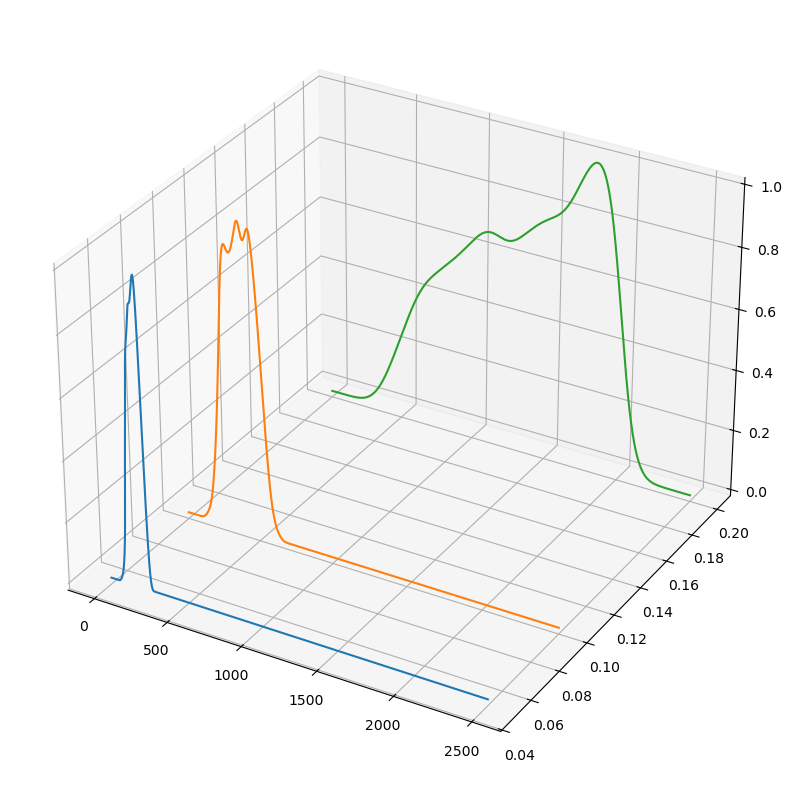

In [20]:
fig = plt.figure(figsize = (14, 10))
ax = fig.add_subplot(111, projection = '3d')

ax.plot(dL_range, np.repeat(0.05, repeats=len(dL_range)), dL_kdes[0, :]/np.max(dL_kdes[0, :]))
ax.plot(dL_range, np.repeat(0.1, repeats=len(dL_range)), dL_kdes[1, :]/np.max(dL_kdes[1, :]))
ax.plot(dL_range, np.repeat(0.2, repeats=len(dL_range)), dL_kdes[2, :]/np.max(dL_kdes[2, :]))

plt.show()

In [21]:
dL_error_LVK = np.zeros(3)  # based on std
dL_range_LVK = np.zeros(3)  # based on quantile range

for i in range(3):
    dL_error_LVK[i] = np.std(dL_array[i, :])/np.median(dL_array[i, :])*100
    dL_range_LVK[i] = quantile_range(dL_array[i, :], 0.158, 0.842)/2/np.median(dL_array[i, :])*100
    print("std based error: ", dL_error_LVK[i], "and median based error: ", dL_range_LVK[i])

std based error:  20.343857517013404 and median based error:  22.19479259264158
std based error:  25.205027765158867 and median based error:  27.904983251740656
std based error:  31.03915074054043 and median based error:  35.79050299367413


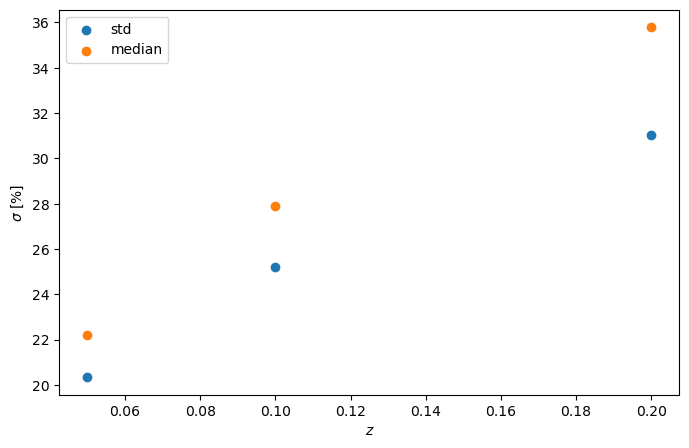

In [22]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, label='std')
ax1.scatter(z_LVK_range, dL_range_LVK, label='median')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Standard deviations**

In [23]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_error_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [24]:
popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_error_LVK)
popt_lin_LVK, _ = curve_fit(func_lin, z_LVK_range, dL_error_LVK)

C:\Users\klera\AppData\Local\Temp\ipykernel_6380\3262714969.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_error_LVK)


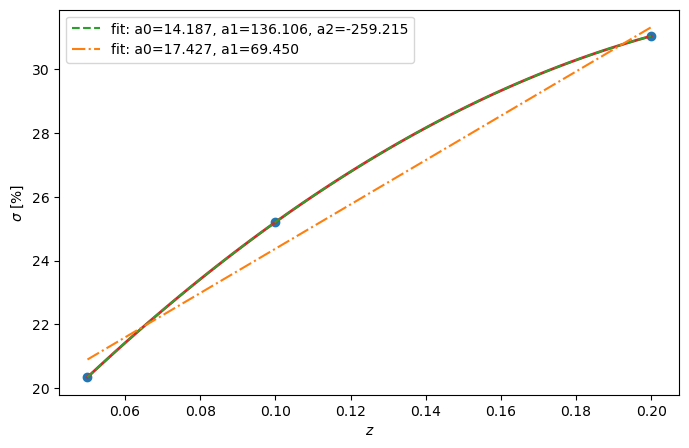

In [25]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_LVK))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Medians**

In [26]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_range_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [27]:
popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_range_LVK)
popt_lin_LVK, _ = curve_fit(func_lin, z_LVK_range, dL_range_LVK)

C:\Users\klera\AppData\Local\Temp\ipykernel_6380\2374793773.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_range_LVK)


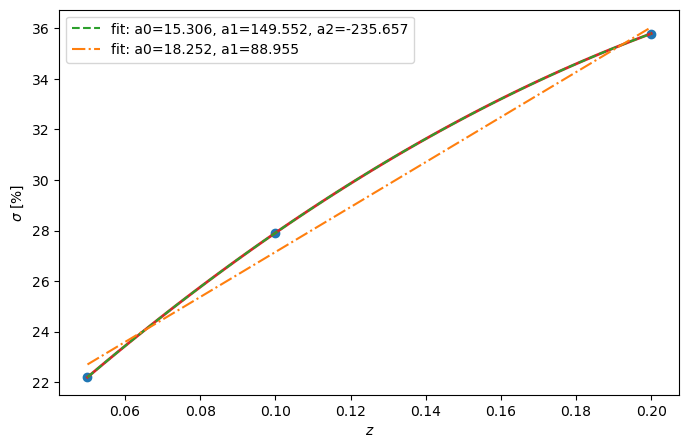

In [28]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_range_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_LVK))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**CE samples**

In [29]:
N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[3:]

dL_array = np.zeros((len(data_files), N_draw_samples))
dL_kdes = np.zeros((len(data_files), dL_res))

dL_range = np.linspace(0, 20000, dL_res)

for idx, name in enumerate(data_files):
    dL_array[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes[idx, :] = dL_kde(dL_range)

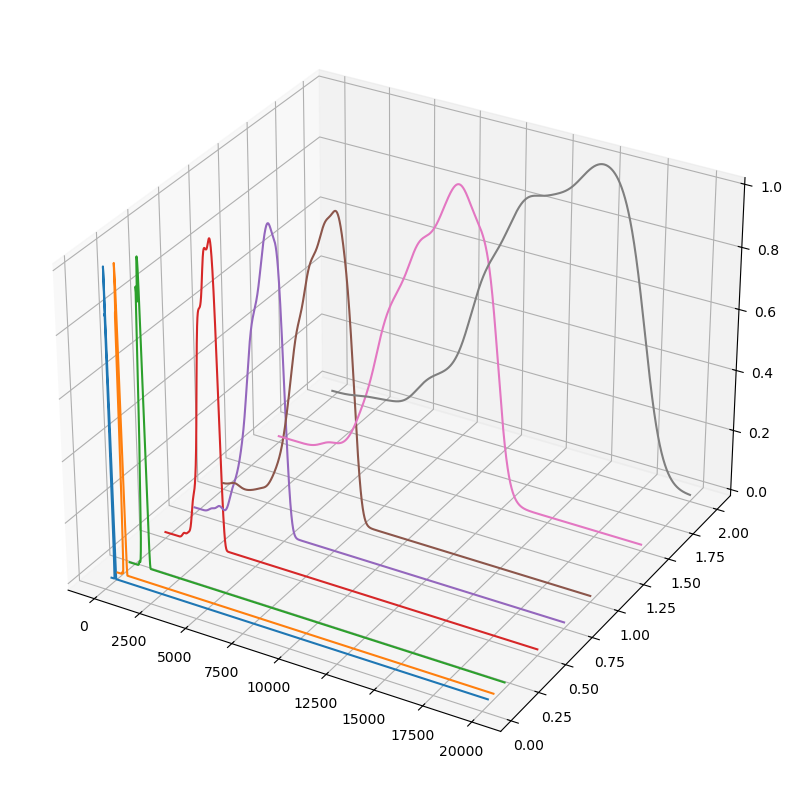

In [30]:
fig = plt.figure(figsize = (14, 10))
ax = fig.add_subplot(111, projection = '3d')

ax.plot(dL_range, np.repeat(0.05, repeats=len(dL_range)), dL_kdes[0, :]/np.max(dL_kdes[0, :]))
ax.plot(dL_range, np.repeat(0.1, repeats=len(dL_range)), dL_kdes[1, :]/np.max(dL_kdes[1, :]))
ax.plot(dL_range, np.repeat(0.2, repeats=len(dL_range)), dL_kdes[2, :]/np.max(dL_kdes[2, :]))
ax.plot(dL_range, np.repeat(0.5, repeats=len(dL_range)), dL_kdes[3, :]/np.max(dL_kdes[3, :]))
ax.plot(dL_range, np.repeat(0.75, repeats=len(dL_range)), dL_kdes[4, :]/np.max(dL_kdes[4, :]))
ax.plot(dL_range, np.repeat(1.0, repeats=len(dL_range)), dL_kdes[5, :]/np.max(dL_kdes[5, :]))
ax.plot(dL_range, np.repeat(1.5, repeats=len(dL_range)), dL_kdes[6, :]/np.max(dL_kdes[6, :]))
ax.plot(dL_range, np.repeat(2.0, repeats=len(dL_range)), dL_kdes[7, :]/np.max(dL_kdes[7, :]))

plt.show()

In [31]:
dL_error_CE = np.zeros(8)
dL_range_CE = np.zeros(8)

for i in range(8):
    dL_error_CE[i] = np.std(dL_array[i, :])/np.median(dL_array[i, :])*100
    dL_range_CE[i] = quantile_range(dL_array[i, :], 0.158, 0.842)/2/np.median(dL_array[i, :])*100    
    print("std based error: ", dL_error_CE[i], "and median based error: ", dL_range_CE[i])

std based error:  6.9023001996492725 and median based error:  7.251029474139944
std based error:  9.05972144460543 and median based error:  9.470176299145017
std based error:  11.181824109455512 and median based error:  11.818876998745223
std based error:  16.164138889078664 and median based error:  17.158780602834355
std based error:  19.078145928575417 and median based error:  19.725764677841163
std based error:  20.11017254242131 and median based error:  21.454951333237222
std based error:  22.521660212475126 and median based error:  25.01277384320324
std based error:  24.404835913102822 and median based error:  26.265648774999807


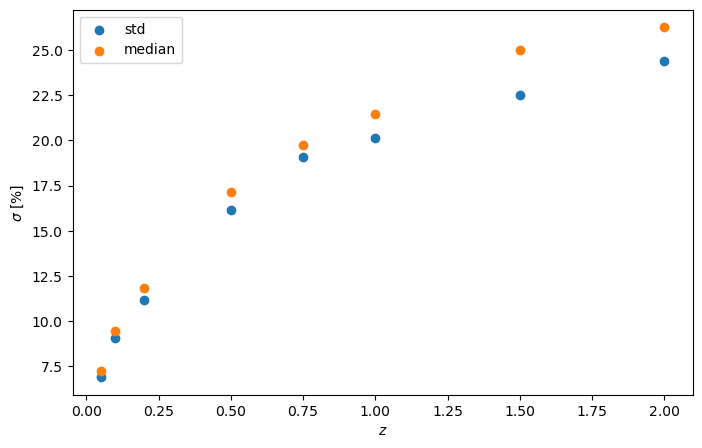

In [32]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE, label='std')
ax1.scatter(z_CE_range, dL_range_CE, label='median')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Standard deviations**

In [33]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_error_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [34]:
popt_CE, pcov_CE = curve_fit(func_quad, z_CE_range, dL_error_CE)
popt_lin_CE, pcov_CE = curve_fit(func_lin, z_CE_range, dL_error_CE)

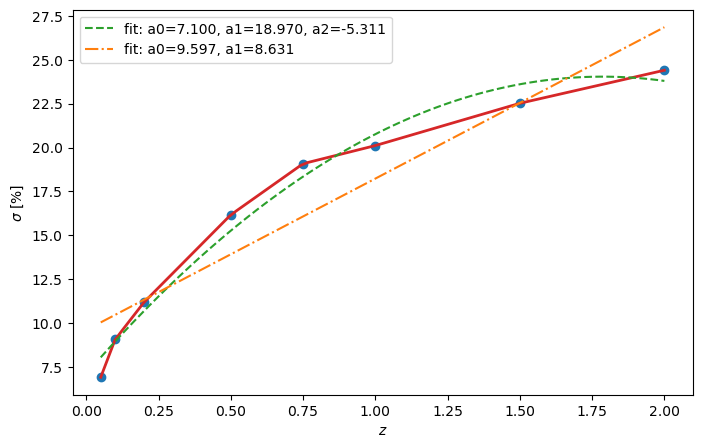

In [35]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_CE))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Medians**

In [36]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_range_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [37]:
popt_CE, pcov_CE = curve_fit(func_quad, z_CE_range, dL_range_CE)
popt_lin_CE, pcov_CE = curve_fit(func_lin, z_CE_range, dL_range_CE)

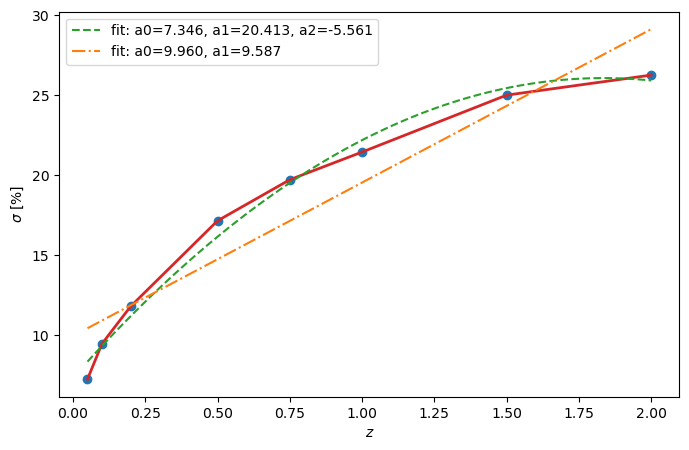

In [38]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_range_CE)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_CE))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

*Comparison*

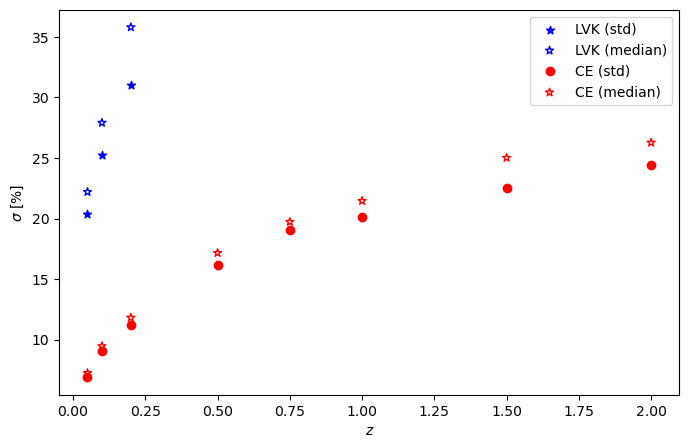

In [39]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, marker='*', c='blue', label='LVK (std)')
ax1.scatter(z_LVK_range, dL_range_LVK, marker='*', facecolors='none', edgecolors='blue', label='LVK (median)')
ax1.scatter(z_CE_range, dL_error_CE, c='r', label='CE (std)')
ax1.scatter(z_CE_range, dL_range_CE, marker='*', facecolors='none', edgecolors='red', label='CE (median)')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

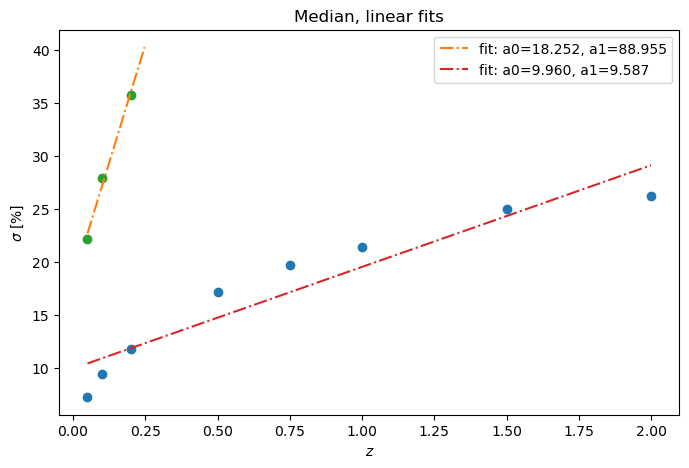

In [46]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_range_LVK, c='tab:green')
plt.plot(z_detailed[z_detailed<0.25], func_lin(z_detailed[z_detailed<0.25], *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK))

ax1.scatter(z_CE_range, dL_range_CE, c='tab:blue')
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:red', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()
ax1.set_title('Median, linear fits')

plt.show()

Saving the linear interpolations

In [49]:
np.savez('std_linear_interpolations.npz', LVK_interpolation = popt_lin_LVK, CE_interpolation = popt_lin_CE)